In [1]:
# Just setting up the environment
import os
import logging
import warnings
import pandas as pd
import numpy as np
import duckdb
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, precision_recall_curve, average_precision_score,
    ConfusionMatrixDisplay
)
from sklearn.pipeline import Pipeline
from sklearn.utils.class_weight import compute_class_weight
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.model_selection import GridSearchCV

from google.colab import drive
drive.mount('/content/drive')

warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)

logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s — %(levelname)s — %(message)s',
    handlers=[
        logging.FileHandler('pipeline.log'),
        logging.StreamHandler()
    ]
)
logger = logging.getLogger(__name__)

plt.style.use('seaborn-v0_8-whitegrid')
PALETTE   = ['#2E86AB', '#E84855', '#F9C22E', '#3BB273', '#7B2D8B']
FIG_DPI   = 150
FIG_DIR   = 'figures/'
os.makedirs(FIG_DIR, exist_ok=True)

RANDOM_STATE = 42

logger.info('Environment configured successfully.')

Mounted at /content/drive


In [2]:
#getting the files
DATA_DIR = '/content/drive/MyDrive/26 Spring Sem/DS4320/Project 1/'

FILES = {
    'diabetic_readmission_cleaned': os.path.join(DATA_DIR, 'diabetic_readmission_cleaned.csv'),
    'medicines'                   : os.path.join(DATA_DIR, 'medicines.csv'),
    'admission_type_id'           : os.path.join(DATA_DIR, 'admission_type_id.csv'),
    'discharge_disposition_id'    : os.path.join(DATA_DIR, 'discharge_disposition_id.csv'),
    'admission_source_id'         : os.path.join(DATA_DIR, 'admission_source_id.csv'),
}

# Checking that i do have all the files
missing = [name for name, path in FILES.items() if not os.path.exists(path)]
if missing:
    raise FileNotFoundError(
        f"The following data files were not found: {missing}.\n"
        f"Please update DATA_DIR to point to your local data folder."
    )
logger.info('All data files located successfully.')

# Create an in-memory DuckDB connection
con = duckdb.connect(database=':memory:')

# loading each data file as a DuckDB table
for table_name, filepath in FILES.items():
    try:
        type_override = ""
        # overriding medicines table columns to be varchar and not boolean (except encounter_id)
        if table_name == 'medicines':
            df_header = pd.read_csv(filepath, nrows=0)

            medicine_columns_to_varchar = [col for col in df_header.columns if col != 'encounter_id']

            types_dict = {col: 'VARCHAR' for col in medicine_columns_to_varchar}

            if types_dict:
                type_override = f", types={types_dict}"

        con.execute(f"""
            CREATE OR REPLACE TABLE {table_name} AS
            SELECT * FROM read_csv_auto('{filepath}'{type_override})
        """)
        row_count = con.execute(f'SELECT COUNT(*) FROM {table_name}').fetchone()[0]
        logger.info(f'Loaded table [{table_name}] — {row_count:,} rows.')
    except Exception as e:
        logger.error(f'Failed to load {table_name}: {e}')
        raise

logger.info('All tables loaded into DuckDB.')

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [3]:
# query: replacing the numeric codes with descriptive labels so that it the admission_type, discharge_disposition, and admission_source are more easily interpretable

query_human_readable = """
SELECT
    d.encounter_id,
    d.patient_nbr,
    atype.description AS admission_type,
    dd.description AS discharge_disposition,
    src.description AS admission_source,
    d.time_in_hospital,
    d.num_lab_procedures,
    d.num_procedures,
    d.num_medications,
    d.number_outpatient,
    d.number_emergency,
    d.number_inpatient,
    d.number_diagnoses,
    d.weight_missing,
    d.readmitted_30d
FROM diabetic_readmission_cleaned d
LEFT JOIN admission_type_id atype
    ON d.admission_type_id = atype.admission_type_id
LEFT JOIN discharge_disposition_id dd
    ON d.discharge_disposition_id = dd.discharge_disposition_id
LEFT JOIN admission_source_id src
    ON d.admission_source_id = src.admission_source_id
LIMIT 10
"""

df_human = con.execute(query_human_readable).df()
logger.info(f'Query 1 (human-readable) returned {len(df_human)} preview rows.')
print('=== Query 1: Human-Readable Encounter Summary (first 10 rows) ===')
df_human

=== Query 1: Human-Readable Encounter Summary (first 10 rows) ===


,encounter_id,patient_nbr,admission_type,discharge_disposition,admission_source,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses,weight_missing,readmitted_30d
0,2278392,8222157,NULL,"Expired, place unknown. Medicaid only, hospice.",Physician Referral,1,41,0,1,0,0,0,1,1,0
1,149190,55629189,Emergency,Discharged to home,Emergency Room,3,59,0,18,0,0,0,9,1,0
2,64410,86047875,Emergency,Discharged to home,Emergency Room,2,11,5,13,2,0,1,6,1,0
3,500364,82442376,Emergency,Discharged to home,Emergency Room,2,44,1,16,0,0,0,7,1,0
4,16680,42519267,Emergency,Discharged to home,Emergency Room,1,51,0,8,0,0,0,5,1,0
5,35754,82637451,Urgent,Discharged to home,Clinic Referral,3,31,6,16,0,0,0,9,1,0
6,55842,84259809,Elective,Discharged to home,Clinic Referral,4,70,1,21,0,0,0,7,1,0
7,63768,114882984,Emergency,Discharged to home,Emergency Room,5,73,0,12,0,0,0,8,1,0
8,12522,48330783,Urgent,Discharged to home,Transfer from a hospital,13,68,2,28,0,0,0,8,1,0
9,15738,63555939,Elective,Discharged/transferred to SNF,Transfer from a hospital,12,33,3,18,0,0,0,8,1,0


In [4]:
#query: figuring out what admission type has the highest readmission rate

query_by_admission = """
SELECT
    atype.description AS admission_type,
    COUNT(*) AS n_encounters,
    SUM(d.readmitted_30d) AS n_readmitted,
    ROUND(100.0 * SUM(d.readmitted_30d)
          / COUNT(*), 2) AS readmission_rate_pct
FROM diabetic_readmission_cleaned d
LEFT JOIN admission_type_id atype
       ON d.admission_type_id = CAST(atype.admission_type_id AS INTEGER)
GROUP BY atype.description
ORDER BY readmission_rate_pct DESC
"""

df_by_admission = con.execute(query_by_admission).df()
logger.info('Query 2 (readmission by admission type) executed.')
print('=== Query 2: Readmission Rate by Admission Type ===')
df_by_admission

=== Query 2: Readmission Rate by Admission Type ===


,admission_type,n_encounters,n_readmitted,readmission_rate_pct
0,Emergency,53990,6221.0,11.52
1,Urgent,18480,2066.0,11.18
2,NULL,5291,586.0,11.08
3,Elective,18869,1961.0,10.39
4,Not Available,4785,495.0,10.34
5,Newborn,10,1.0,10.00
6,Not Mapped,320,27.0,8.44
7,Trauma Center,21,0.0,0.00


In [5]:
# query: seeing if a change in insulin regimen at discharge means there is a lower readmission rate

query_insulin = """
SELECT
    insulin_status,
    COUNT(*) AS n_encounters,
    SUM(readmitted_30d) AS n_readmitted,
    ROUND(100.0 * SUM(readmitted_30d)
          / COUNT(*), 2) AS readmission_rate_pct
FROM (
    -- Derive insulin status label from the insulin column in the medicines table.
    -- The medicines table has a single 'insulin' column with values like 'Up', 'Down', 'Steady', 'No'.
    SELECT
        d.readmitted_30d,
        m.insulin AS insulin_status
    FROM diabetic_readmission_cleaned d
    JOIN medicines m
      ON d.encounter_id = m.encounter_id
) sub
GROUP BY insulin_status
ORDER BY readmission_rate_pct DESC
"""

df_insulin = con.execute(query_insulin).df()
logger.info('Query 3 (insulin vs readmission) executed.')
print('=== Query 3: Readmission Rate by Insulin Status ===')
df_insulin

=== Query 3: Readmission Rate by Insulin Status ===


,insulin_status,n_encounters,n_readmitted,readmission_rate_pct
0,Down,12218,1698.0,13.90
1,Up,11316,1470.0,12.99
2,Steady,30849,3433.0,11.13
3,No,47383,4756.0,10.04


In [6]:
#query: pulling the dataset made in duckdb into pandas df

query_model_data = """
SELECT * FROM diabetic_readmission_cleaned
"""

df_model = con.execute(query_model_data).df()
logger.info(f'Model dataset pulled from DuckDB: {df_model.shape[0]:,} rows × {df_model.shape[1]} cols.')
print(f'Model DataFrame shape: {df_model.shape}')
print(f'Target class distribution:')
print(df_model['readmitted_30d'].value_counts(normalize=True).rename({0:'Not readmitted',1:'Readmitted <30d'}).round(4))

Model DataFrame shape: (101766, 2275)
Target class distribution:
readmitted_30d
Not readmitted     0.8884
Readmitted <30d    0.1116
Name: proportion, dtype: float64


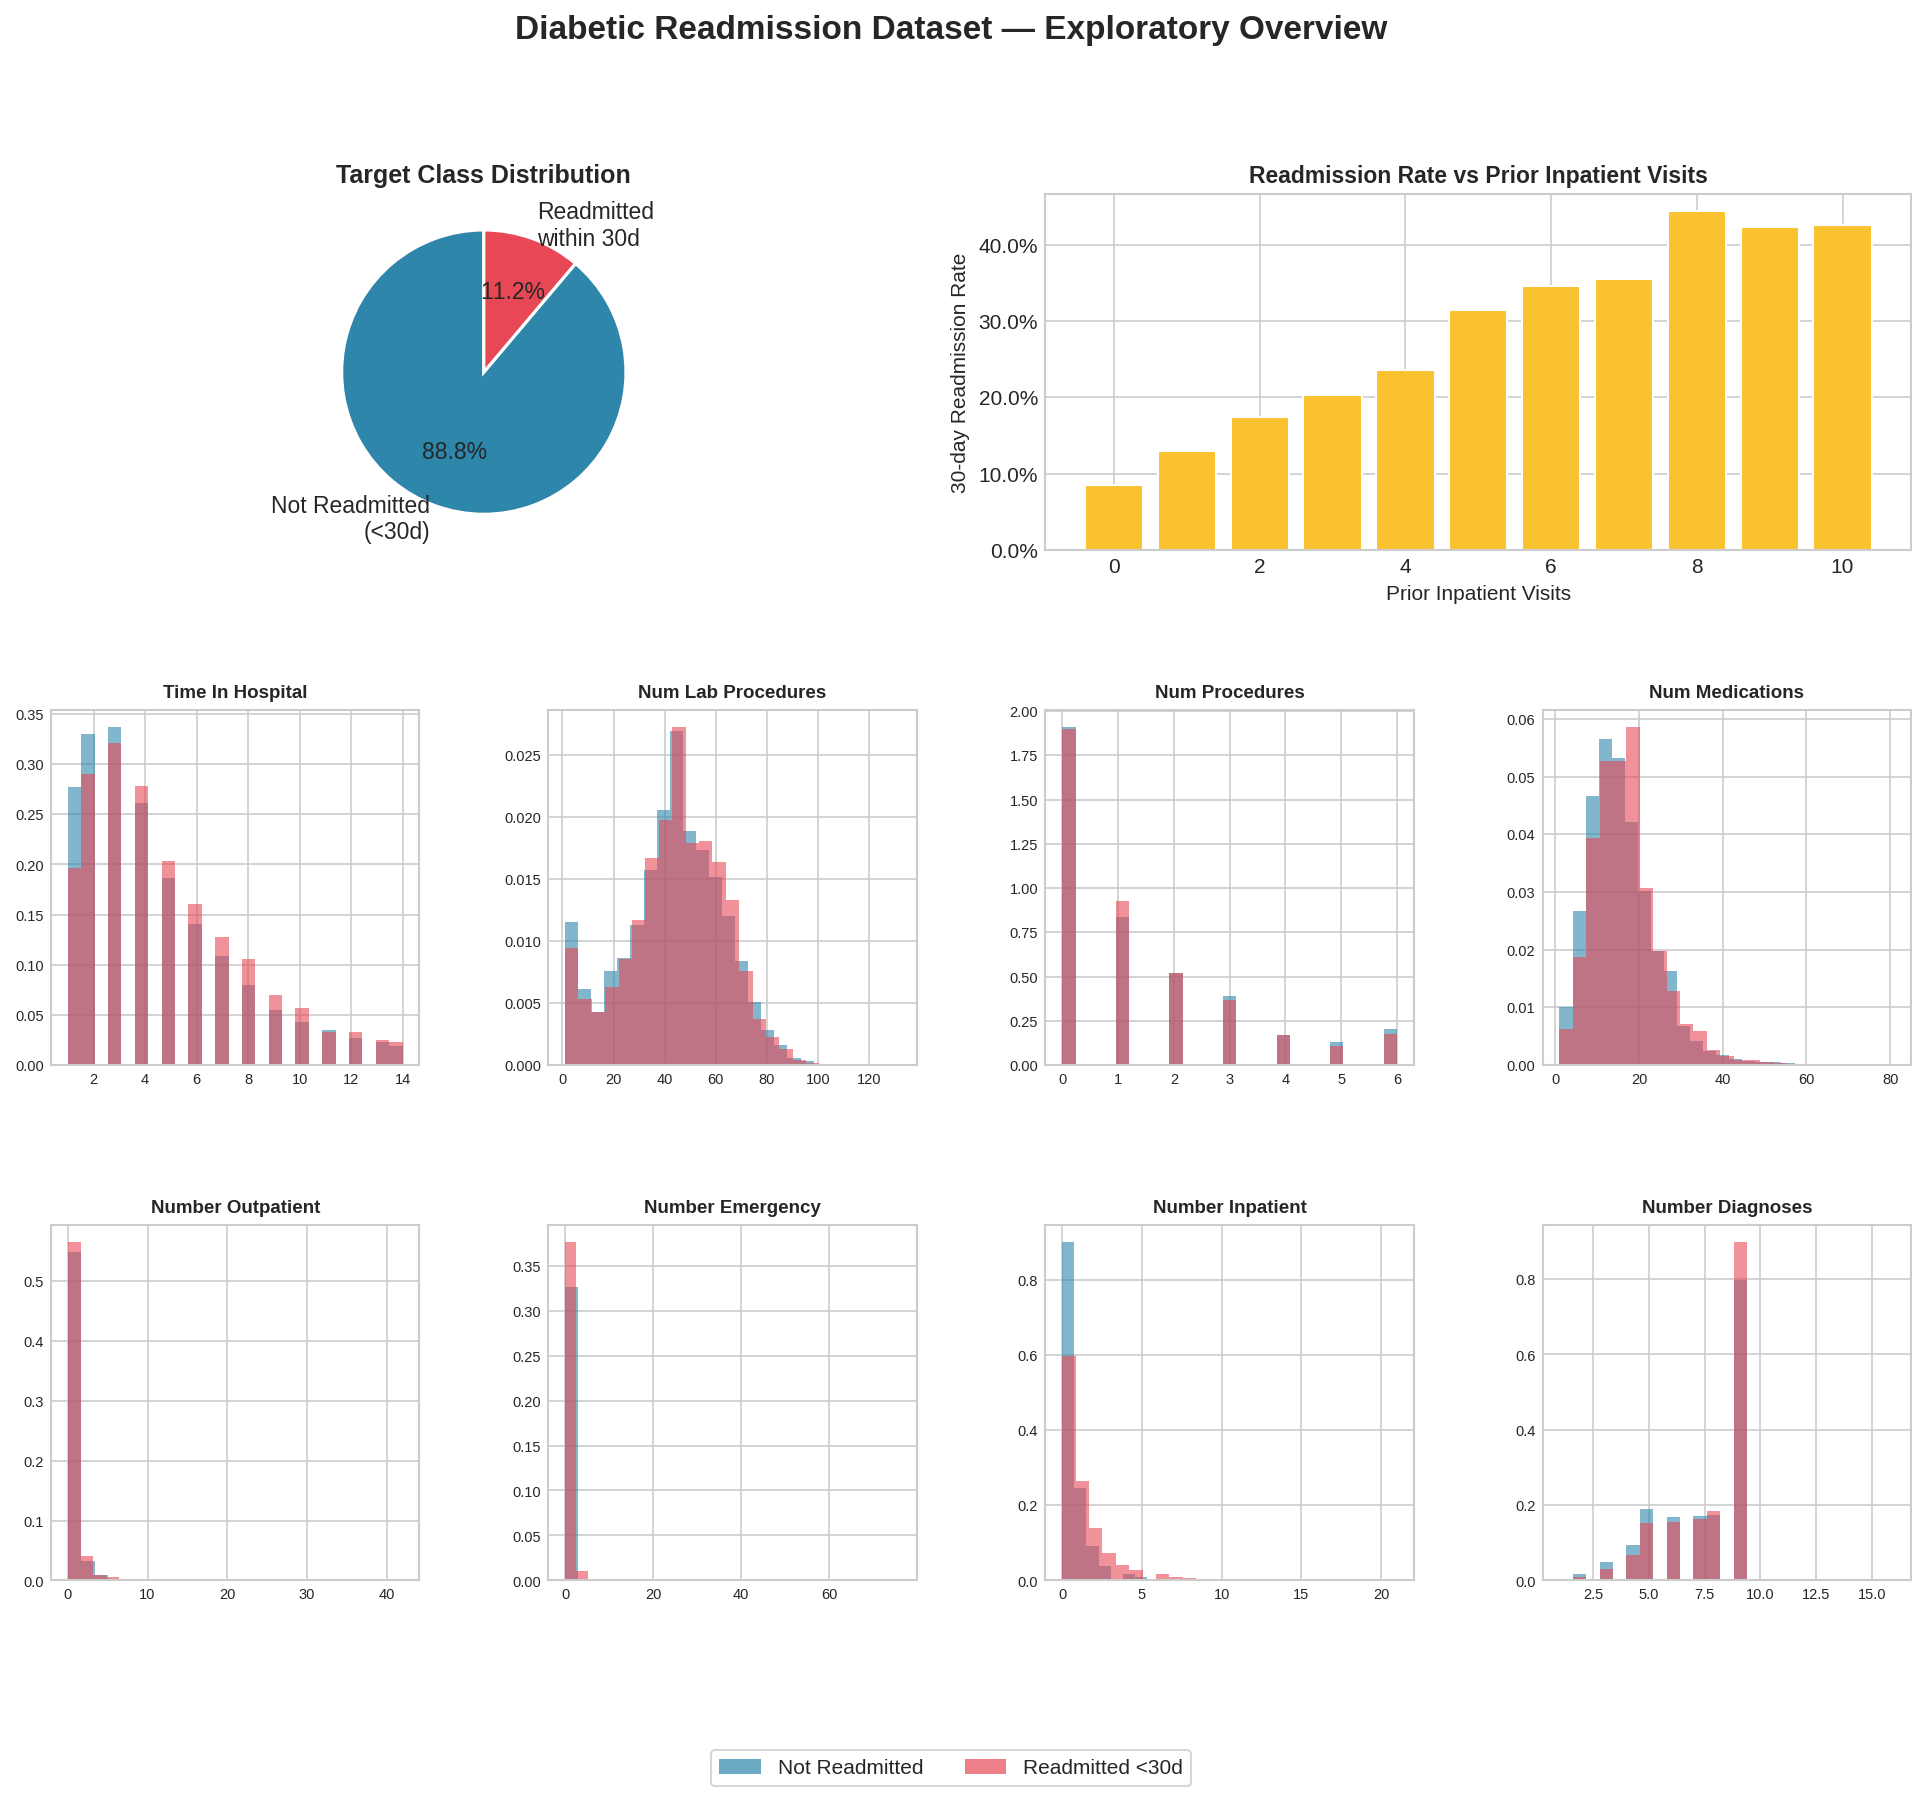

In [7]:
#eda...yay...

numeric_features = [
    'time_in_hospital', 'num_lab_procedures', 'num_procedures',
    'num_medications', 'number_outpatient', 'number_emergency',
    'number_inpatient', 'number_diagnoses'
]

fig = plt.figure(figsize=(16, 12), dpi=FIG_DPI)
fig.suptitle(
    'Diabetic Readmission Dataset — Exploratory Overview',
    fontsize=16, fontweight='bold', y=0.98
)
gs = gridspec.GridSpec(3, 4, figure=fig, hspace=0.45, wspace=0.35)

# pie chart of readmitted/not readmitted
ax_pie = fig.add_subplot(gs[0, :2])
counts = df_model['readmitted_30d'].value_counts()
labels = ['Not Readmitted\n(<30d)', 'Readmitted\nwithin 30d']
ax_pie.pie(
    counts, labels=labels, colors=[PALETTE[0], PALETTE[1]],
    autopct='%1.1f%%', startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5},
    textprops={'fontsize': 11}
)
ax_pie.set_title('Target Class Distribution', fontsize=12, fontweight='bold')

# readmission rate by number of inpatient visits
ax_inp = fig.add_subplot(gs[0, 2:])
inp_rate = (
    df_model.groupby('number_inpatient')['readmitted_30d']
    .mean().reset_index()
    .rename(columns={'readmitted_30d': 'readmission_rate'})
    .query('number_inpatient <= 10')  # Cap for readability
)
ax_inp.bar(
    inp_rate['number_inpatient'], inp_rate['readmission_rate'],
    color=PALETTE[2], edgecolor='white'
)
ax_inp.set_xlabel('Prior Inpatient Visits', fontsize=10)
ax_inp.set_ylabel('30-day Readmission Rate', fontsize=10)
ax_inp.set_title('Readmission Rate vs Prior Inpatient Visits', fontsize=11, fontweight='bold')
ax_inp.yaxis.set_major_formatter(matplotlib.ticker.PercentFormatter(xmax=1))

# histograms of key numeric features split by readmission label
for i, feat in enumerate(numeric_features):
    row, col = divmod(i, 4)
    ax = fig.add_subplot(gs[row + 1, col])
    for label, color in zip([0, 1], [PALETTE[0], PALETTE[1]]):
        subset = df_model.loc[df_model['readmitted_30d'] == label, feat]
        ax.hist(
            subset, bins=25, alpha=0.6,
            color=color, edgecolor='none', density=True
        )
    ax.set_title(feat.replace('_', ' ').title(), fontsize=9, fontweight='bold')
    ax.set_xlabel('')
    ax.tick_params(labelsize=7)

# Shared legend for histogram panels
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=PALETTE[0], alpha=0.7, label='Not Readmitted'),
    Patch(facecolor=PALETTE[1], alpha=0.7, label='Readmitted <30d')
]
fig.legend(handles=legend_elements, loc='lower center', ncol=2,
           fontsize=10, frameon=True, bbox_to_anchor=(0.5, -0.01))

plt.savefig(os.path.join(FIG_DIR, 'eda_overview.png'), bbox_inches='tight', dpi=FIG_DPI)
plt.show()
logger.info('EDA overview figure saved.')

In [8]:
#preparing the features

# Dropping the identifier columns b/c they have no predictive value
DROP_COLS = ['encounter_id', 'patient_nbr']
TARGET    = 'readmitted_30d'

feature_cols = [c for c in df_model.columns if c not in DROP_COLS + [TARGET]]
X = df_model[feature_cols].copy()
y = df_model[TARGET].copy()

# making sure all columns are numeric (fillna with 0 as a safety net)
X = X.apply(pd.to_numeric, errors='coerce').fillna(0)

logger.info(f'Feature matrix shape: {X.shape}')
logger.info(f'Target distribution — 0: {(y==0).sum():,}  |  1: {(y==1).sum():,}')

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)
logger.info(f'Train size: {len(X_train):,}  |  Test size: {len(X_test):,}')

print(f'Training set: {X_train.shape[0]:,} rows | Test set: {X_test.shape[0]:,} rows')
print(f'Features used: {X_train.shape[1]}')

Training set: 81,412 rows | Test set: 20,354 rows
Features used: 2272


In [9]:
# modeling as a logistic regression...let's see how this goes
#doing this because this is the interpretable option for binary classification

lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        solver='lbfgs',
        random_state=RANDOM_STATE
    ))
])

try:
    lr_pipeline.fit(X_train, y_train)
    y_pred_lr   = lr_pipeline.predict(X_test)
    y_proba_lr  = lr_pipeline.predict_proba(X_test)[:, 1]
    auc_lr      = roc_auc_score(y_test, y_proba_lr)
    ap_lr       = average_precision_score(y_test, y_proba_lr)
    logger.info(f'Logistic Regression — AUC-ROC: {auc_lr:.4f} | Avg Precision: {ap_lr:.4f}')
    print('=== Logistic Regression Classification Report ===')
    print(classification_report(y_test, y_pred_lr, target_names=['Not Readmitted', 'Readmitted <30d']))
    print(f'AUC-ROC: {auc_lr:.4f}  |  Average Precision: {ap_lr:.4f}')
except Exception as e:
    logger.error(f'Logistic Regression training failed: {e}')
    raise

=== Logistic Regression Classification Report ===
                 precision    recall  f1-score   support

 Not Readmitted       0.92      0.65      0.76     18083
Readmitted <30d       0.16      0.55      0.25      2271

       accuracy                           0.64     20354
      macro avg       0.54      0.60      0.51     20354
   weighted avg       0.84      0.64      0.71     20354

AUC-ROC: 0.6356  |  Average Precision: 0.1933


In [10]:
# modeling as a random forest classifier b/c might do better if the relationship is non-linear

# defining the parameter grid for the Random Forest Classifier
param_grid = {
    'n_estimators': [100, 150, 200],
    'max_depth': [10, 12, 15],
    'min_samples_leaf': [10, 15, 20]
}

# initizalizing the Random Forest Classifier
rf_base_model = RandomForestClassifier(
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1
)

# initizalizing GridSearchCV
grid_search = GridSearchCV(
    estimator=rf_base_model,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=3,
    n_jobs=-1,
    verbose=1
)

try:
    logger.info('Starting Random Forest hyperparameter tuning...')
    grid_search.fit(X_train, y_train)

    best_rf_model = grid_search.best_estimator_
    best_params = grid_search.best_params_
    best_score = grid_search.best_score_

    logger.info(f'Best Random Forest parameters: {best_params}')
    logger.info(f'Best cross-validation AUC-ROC score: {best_score:.4f}')

    y_pred_rf = best_rf_model.predict(X_test)
    y_proba_rf = best_rf_model.predict_proba(X_test)[:, 1]
    auc_rf = roc_auc_score(y_test, y_proba_rf)
    ap_rf = average_precision_score(y_test, y_proba_rf)
    logger.info(f'Best Random Forest Model (Test Set) — AUC-ROC: {auc_rf:.4f} | Avg Precision: {ap_rf:.4f}')

    print('=== Random Forest Hyperparameter Tuning Results ===')
    print(f'Best parameters found: {best_params}')
    print(f'Best cross-validation AUC-ROC score: {best_score:.4f}')
    print('\n=== Best Random Forest Model Classification Report (Test Set) ===')
    print(classification_report(y_test, y_pred_rf, target_names=['Not Readmitted', 'Readmitted <30d']))
    print(f'AUC-ROC: {auc_rf:.4f}  |  Average Precision: {ap_rf:.4f}')

except Exception as e:
    logger.error(f'Random Forest hyperparameter tuning or training failed: {e}')
    raise


Fitting 3 folds for each of 27 candidates, totalling 81 fits
=== Random Forest Hyperparameter Tuning Results ===
Best parameters found: {'max_depth': 15, 'min_samples_leaf': 10, 'n_estimators': 200}
Best cross-validation AUC-ROC score: 0.6478

=== Best Random Forest Model Classification Report (Test Set) ===
                 precision    recall  f1-score   support

 Not Readmitted       0.93      0.62      0.74     18083
Readmitted <30d       0.17      0.61      0.26      2271

       accuracy                           0.62     20354
      macro avg       0.55      0.61      0.50     20354
   weighted avg       0.84      0.62      0.69     20354

AUC-ROC: 0.6581  |  Average Precision: 0.2033


In [11]:
# Performance Summary Table of the two different models

from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

results = []
for name, y_pred, y_proba in [
    ('Logistic Regression', y_pred_lr, y_proba_lr),
    ('Random Forest',       y_pred_rf, y_proba_rf),
]:
    results.append({
        'Model'           : name,
        'Accuracy'        : round(accuracy_score(y_test, y_pred), 4),
        'Precision (pos)' : round(precision_score(y_test, y_pred), 4),
        'Recall (pos)'    : round(recall_score(y_test, y_pred), 4),
        'F1 (pos)'        : round(f1_score(y_test, y_pred), 4),
        'AUC-ROC'         : round(roc_auc_score(y_test, y_proba), 4),
        'Avg Precision'   : round(average_precision_score(y_test, y_proba), 4),
    })

summary_df = pd.DataFrame(results).set_index('Model')
logger.info('Performance summary computed.')
print('Model Performance Summary')
summary_df

Model Performance Summary


,Accuracy,Precision (pos),Recall (pos),F1 (pos),AUC-ROC,Avg Precision
Model,,,,,,
Logistic Regression,0.6403,0.1649,0.5469,0.2533,0.6356,0.1933
Random Forest,0.6204,0.1679,0.6072,0.2630,0.6581,0.2033


**Analysis rationale:**

Initially I started with a logistic regression model, but I suspected that there might be a non-linear relationship between the variables which would make the logisitc regression model not the best choice. Going off this hunch, I tried a random forest model. Now the Random Forest model technically had a lower accuracy than the logistic regression, but it did have a higher recall, which means that there were less people slipping through who would be readmitted and more false positive flags for readmittance. Considering the domain and the risks of not flagging for readmittance, the random forest model is a better option as it would be better to prep more people than miss people who would need to then be readmitted.

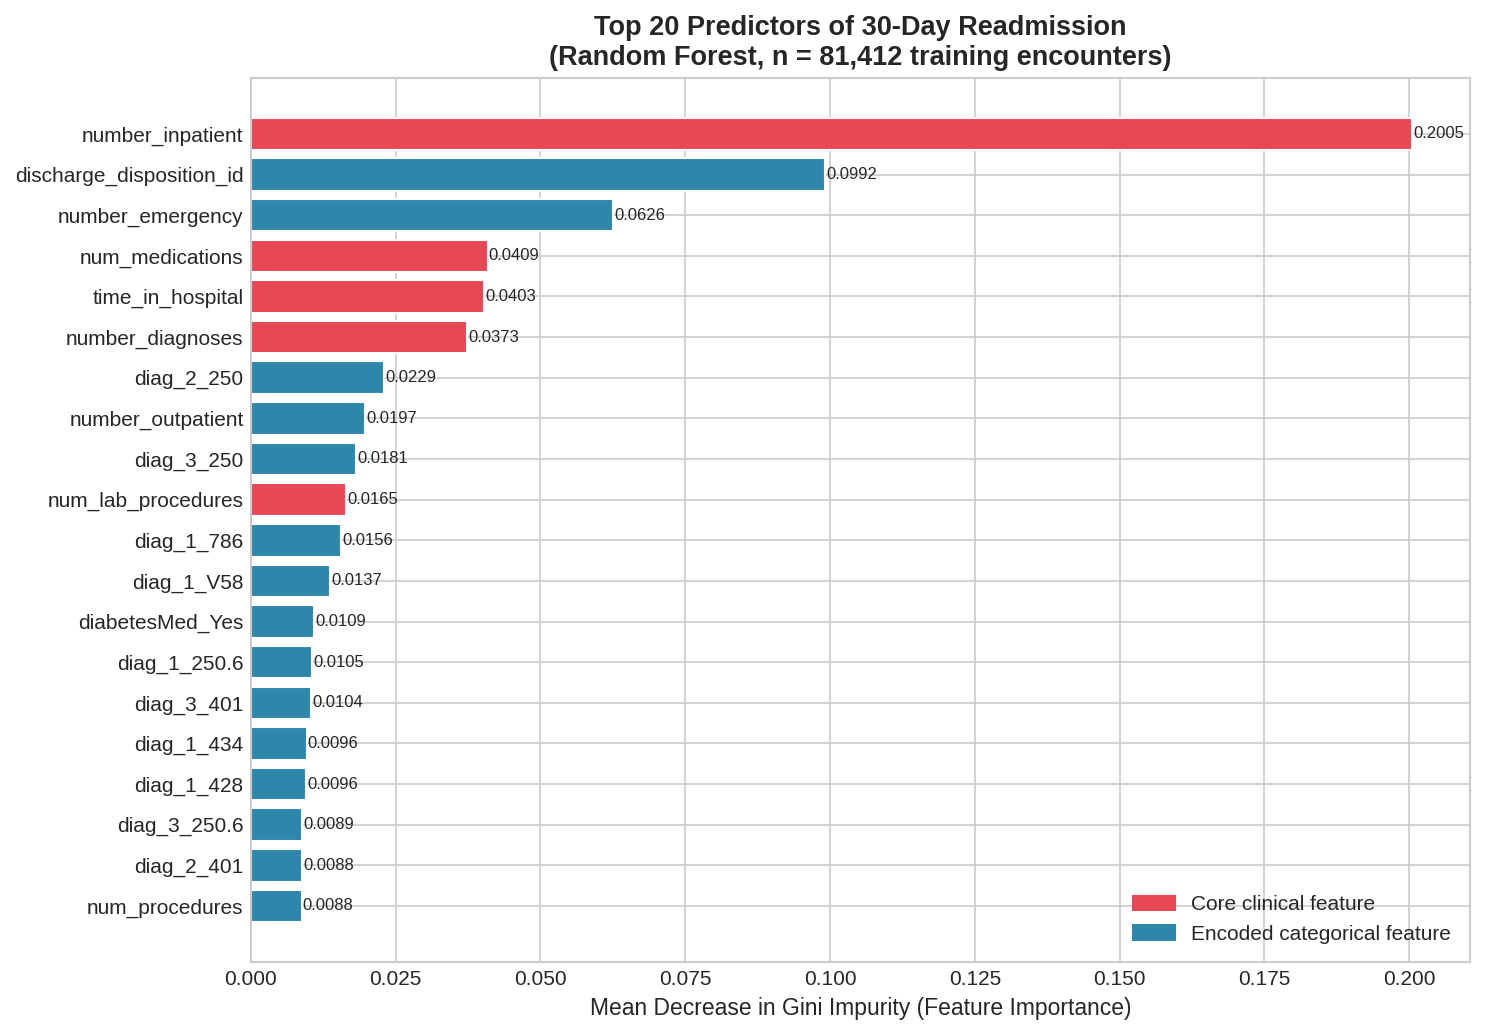

In [12]:
# Random Forest Feature Importance (Top 20) - using to indicate strongest predictors

importances = pd.Series(
    best_rf_model.feature_importances_,
    index=feature_cols
).sort_values(ascending=False)

top_n    = 20
top_feats = importances.head(top_n)

# highlighting a few known important clinical features
clinical_highlight = {'number_inpatient', 'time_in_hospital', 'num_medications',
                       'number_diagnoses', 'num_lab_procedures'}
bar_colors = [
    PALETTE[1] if f in clinical_highlight else PALETTE[0]
    for f in top_feats.index
]

fig, ax = plt.subplots(figsize=(10, 7), dpi=FIG_DPI)

bars = ax.barh(
    top_feats.index[::-1],
    top_feats.values[::-1],
    color=bar_colors[::-1],
    edgecolor='white'
)

ax.set_xlabel('Mean Decrease in Gini Impurity (Feature Importance)', fontsize=11)
ax.set_title(
    f'Top {top_n} Predictors of 30-Day Readmission\n(Random Forest, n = {len(X_train):,} training encounters)',
    fontsize=13, fontweight='bold'
)

for bar in bars:
    width = bar.get_width()
    ax.text(width + 0.0002, bar.get_y() + bar.get_height() / 2,
            f'{width:.4f}', va='center', ha='left', fontsize=8)

from matplotlib.patches import Patch
legend_elems = [
    Patch(color=PALETTE[1], label='Core clinical feature'),
    Patch(color=PALETTE[0], label='Encoded categorical feature')
]
ax.legend(handles=legend_elems, fontsize=10, loc='lower right')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'feature_importance.png'), bbox_inches='tight', dpi=FIG_DPI)
plt.show()
logger.info('Feature importance figure saved.')

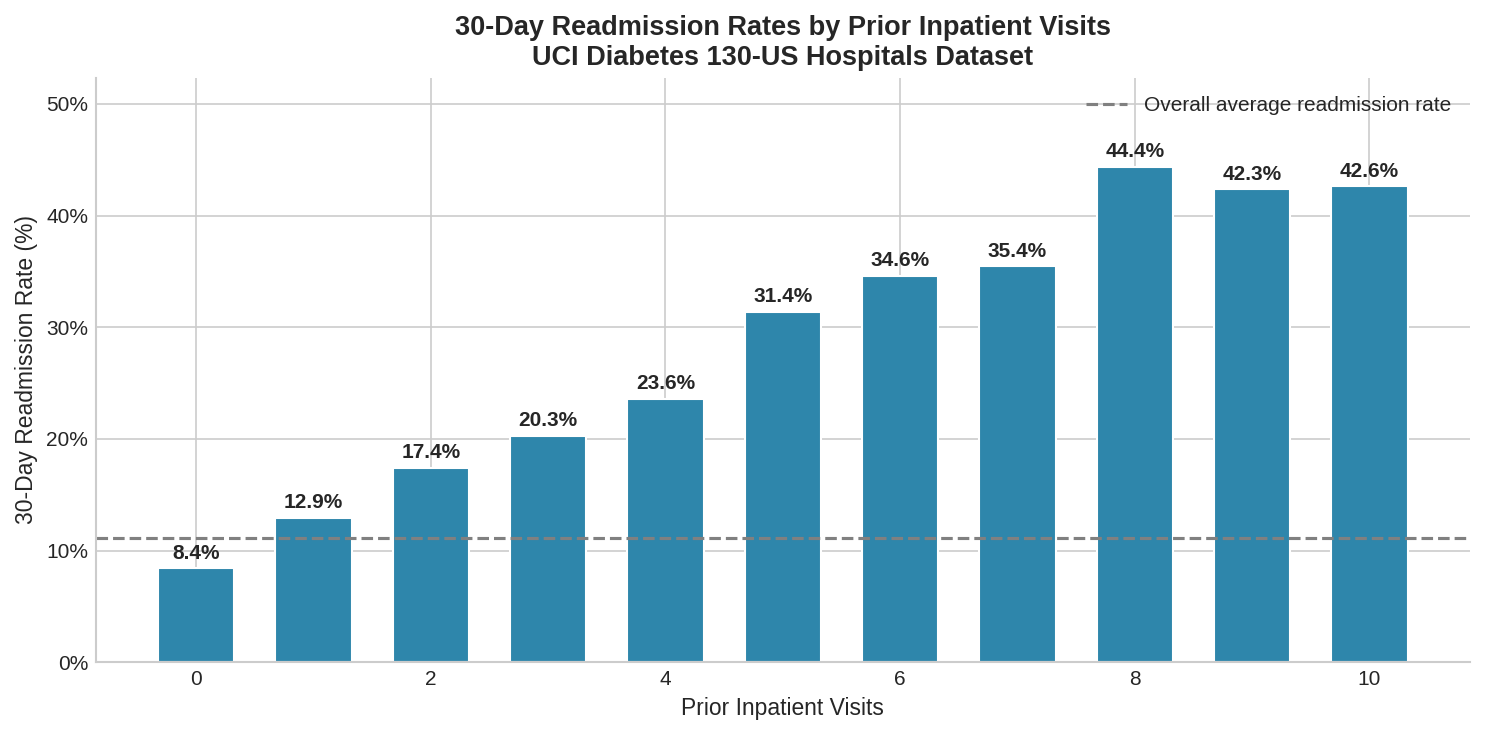

In [13]:
# Press Release / Publication Chart: Readmission Rate by Number of Inpatient Visits
# making a simple chart more suited for a press release considering non-domain people would be viewing

plot_df = inp_rate

fig, ax = plt.subplots(figsize=(10, 5), dpi=FIG_DPI)

bar_colors = [PALETTE[0]] * len(plot_df)

bars = ax.bar(
    plot_df['number_inpatient'],
    plot_df['readmission_rate'],
    color=bar_colors, edgecolor='white', width=0.65
)

ax.axhline(y=df_model['readmitted_30d'].mean(), color='gray',
           linestyle='--', lw=1.5, label='Overall average readmission rate')

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, height + 0.005,
            f'{height:.1%}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_xlabel('Prior Inpatient Visits', fontsize=11)
ax.set_ylabel('30-Day Readmission Rate (%)', fontsize=11)
ax.set_title(
    '30-Day Readmission Rates by Prior Inpatient Visits\nUCI Diabetes 130-US Hospitals Dataset',
    fontsize=13, fontweight='bold'
)
ax.yaxis.set_major_formatter(matplotlib.ticker.PercentFormatter(xmax=1))
ax.legend(fontsize=10)
ax.set_ylim(0, plot_df['readmission_rate'].max() * 1.18)
sns.despine(left=False, bottom=False)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'readmission_by_number_inpatient.png'), bbox_inches='tight', dpi=FIG_DPI)
plt.show()
logger.info('Readmission-by-number-inpatient chart saved.')


### Visualization Rationale

I did a few different visualizations messing around trying to determine what would be the best idea for the press release and comparing the two models more in depth. I choose to create a visualization of the feature importance for the random forest model to see exactly how the model was functioning and what is impacting the readmission results. Based on the visualization of the feature importance, I then made a visualization for the press release that displayed readmittance by the number of inpatient visits in the year prior as that was the most importnat feature. I choose to use this visualization for my press release because I think it is easily understandable for an audience who is not necessarily super familiar with the domain.